# Create population data figure

## Imports

In [1]:
from pathlib import Path
import logging

import numpy as np
import pandas as pd
import pingouin
import matplotlib.pyplot as plt

from gulp2p.preproc.experiment import Experiment, create_expt_df
from gulp2p.preproc import trial as tr
from gulp2p.analysis import head_direction as hd
from gulp2p.viz import plotting

from matplotlib import rcParams
rcParams['pdf.fonttype'] = 42
rcParams['svg.fonttype'] = "none"

### Logging config

In [2]:
log_level = logging.INFO    # log levels: DEBUG, INFO, WARNING, ERROR, CRITICAL
log_format = "{asctime} - {levelname} - {name} - [{filename} {funcName}() {lineno}] - {message}"
logging.basicConfig(format=log_format, level=log_level, style="{") 

logging.getLogger("gulp2p").setLevel(logging.DEBUG)
logger = logging.getLogger(__name__)

## Select Data

### Functions:

In [3]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

### Create trial dataframe:

In [4]:
TIFF_FOLDER = Path(r"Z:\2PImaging\Kerstin\MIMS")

trial_df = tr.create_trial_df(TIFF_FOLDER, CELL_TYPES, GENETIC_TOOLS)

In [5]:
trial_df.head()

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_...,20231109,iGluSnFRxSS2232,iGluSnFR,SS2232,1,1


### Sort into experiments:

In [6]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

2024-09-30 11:35:11,794 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00001.tif
2024-09-30 11:35:11,801 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00002.tif
2024-09-30 11:35:11,807 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00003.tif
2024-09-30 11:35:11,813 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_00004.tif
2024-09-30 11:35:11,819 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not processed: Z:\2PImaging\Kerstin\MIMS\20231109\Fly1_8days_iGluSnFRxSS2232_Stripe_00001.tif
2024-09-30 11:35:11,826 - INFO - gulp2p.preproc.utils - [utils.py load_trial() 639] - trial not pr

In [7]:
expt_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   expt_name         40 non-null     object
 1   trial_paths       40 non-null     object
 2   date              40 non-null     object
 3   line              39 non-null     object
 4   cell_type         39 non-null     object
 5   genetic_tool      39 non-null     object
 6   fly               40 non-null     int64 
 7   trials            40 non-null     object
 8   proc_trial_count  40 non-null     int64 
dtypes: int64(2), object(7)
memory usage: 2.9+ KB


In [8]:
expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,4
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
39,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5


### Load data

In [9]:
# Select only experiments that include processed trials
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]

In [10]:
# Create Experiment objects
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

2024-09-30 11:35:28,838 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-30 11:35:28,844 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_21236\3279863305.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [11]:
# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

In [12]:
print(f"number of processed experiments: {len(processed_expt_df)}")
processed_expt_df.head()

number of processed experiments: 23


,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt
10,20231206_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231206\20231206_D...,20231206,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,10,<gulp2p.preproc.experiment.Experiment object a...
12,20231207_DR019xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,9,<gulp2p.preproc.experiment.Experiment object a...
13,20231207_DR019xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231207\20231207_D...,20231207,DR019xiGluSnFr,DR019,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...
14,20231212_DR018xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,11,<gulp2p.preproc.experiment.Experiment object a...
15,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,3,<gulp2p.preproc.experiment.Experiment object a...


## Create Figures:

### Plot bump profile for each experiment

In [13]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [14]:
for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    print(expt_df_row['expt_name'])
    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name']
    fig.suptitle(fig_title)
    for fmt in PLOT_FORMATS:
        fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)
    plt.close(fig)

2024-09-30 11:35:29,040 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1595 nans / 2611 total elements
2024-09-30 11:35:29,044 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1921 nans / 2613 total elements
2024-09-30 11:35:29,049 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1332 nans / 2612 total elements
2024-09-30 11:35:29,053 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1725 nans / 2611 total elements
2024-09-30 11:35:29,057 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1997 nans / 2612 total elements
2024-09-30 11:35:29,061 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_h

20231206_DR018xiGluSnFr_Fly1


2024-09-30 11:35:29,131 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2013 nans / 2612 total elements
2024-09-30 11:35:29,175 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 18257 nans / 25984 total elements
2024-09-30 11:35:29,203 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 20431 nans / 25984 total elements
2024-09-30 11:35:29,251 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 24041 nans / 25984 total elements
2024-09-30 11:35:33,457 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1376 nans / 2323 total elements
2024-09-30 11:35:33,461 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_inte

20231207_DR019xiGluSnFr_Fly1


2024-09-30 11:35:33,605 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10285 nans / 20895 total elements
2024-09-30 11:35:33,643 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 13887 nans / 20895 total elements
2024-09-30 11:35:37,692 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1526 nans / 2322 total elements
2024-09-30 11:35:37,694 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 186 nans / 285 total elements
2024-09-30 11:35:37,699 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1636 nans / 2323 total elements
2024-09-30 11:35:37,704 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal

...

2024-09-30 11:37:17,584 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 403 nans / 2621 total elements
2024-09-30 11:37:17,593 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 636 nans / 2621 total elements
2024-09-30 11:37:17,610 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 689 nans / 2621 total elements
2024-09-30 11:37:17,619 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 727 nans / 2621 total elements
2024-09-30 11:37:17,628 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 653 nans / 2621 total elements
2024-09-30 11:37:17,639 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_d

20240708_DR015xiGluSnfR_Fly1


2024-09-30 11:37:29,087 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 5680 nans / 5969 total elements
2024-09-30 11:37:33,646 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1913 nans / 2983 total elements
2024-09-30 11:37:33,655 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2669 nans / 2985 total elements
2024-09-30 11:37:33,666 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1565 nans / 2985 total elements
2024-09-30 11:37:33,676 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 701 nans / 2983 total elements
2024-09-30 11:37:33,685 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_he

20240708_DR015xiGluSnfR_Fly2


2024-09-30 11:37:33,724 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2483 nans / 2985 total elements
2024-09-30 11:37:33,736 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1849 nans / 2983 total elements
2024-09-30 11:37:33,875 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2192 nans / 2986 total elements
2024-09-30 11:37:33,947 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 8712 nans / 14922 total elements
2024-09-30 11:37:33,977 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10570 nans / 14922 total elements
2024-09-30 11:37:34,033 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_interna

### Plot population data:

In [15]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-09-30 11:37:40,461 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.


2024-09-30 11:37:40,470 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_21236\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [16]:
type(expt.upper_deltaf)

numpy.ndarray

In [17]:
stat_df_dicts = []
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']
    data_point = {"expt_name": expt_df_row['expt_name']}
    for bump_region in ['upper', 'lower', 'mean']:
        # HD offset variance
        hd_offset = hd.get_hd_offset(expt, mode=bump_region)
        circ_var = hd.get_circ_var(hd_offset)
        data_point[f"{bump_region}_bump_hd_offset_circ_var"] = circ_var

        # Cosine fit
        if bump_region == 'upper':
            aligned_bumps = hd.align_bumps(expt.upper_deltaf, min_r=0.15, offset=3)
        if bump_region == 'lower':
            aligned_bumps = hd.align_bumps(expt.lower_deltaf, min_r=0.15, offset=3)
        if bump_region == 'mean':
            upper_aligned_bump = hd.align_bumps(expt.upper_deltaf, min_r=0.15, offset=3)
            lower_aligned_bump = hd.align_bumps(expt.lower_deltaf, min_r=0.15, offset=3)
            aligned_bumps = np.mean(np.array([upper_aligned_bump, lower_aligned_bump]), axis=0)

        mean_bump = np.mean(aligned_bumps, axis=0)
        parameters, covariance, r_squared = hd.get_cos_fit(mean_bump, cos_func=hd.standard_cos_func)

        data_point[f"{bump_region}_bump_r2"] = r_squared
        data_point[f"{bump_region}_bump_cosine_params"] = parameters

    stat_df_dicts.append(data_point)
stats_df = pd.DataFrame(stat_df_dicts)

2024-09-30 11:37:40,656 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 18257 nans / 25984 total elements
2024-09-30 11:37:41,221 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 20431 nans / 25984 total elements
2024-09-30 11:37:41,817 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 24041 nans / 25984 total elements
2024-09-30 11:37:42,875 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10393 nans / 20895 total elements
2024-09-30 11:37:43,320 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 10285 nans / 20895 total elements
2024-09-30 11:37:43,803 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_

In [18]:
processed_expt_df = pd.merge(processed_expt_df, stats_df, on="expt_name")

In [19]:
processed_expt_df.tail()

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count,expt,upper_bump_hd_offset_circ_var,upper_bump_r2,upper_bump_cosine_params,lower_bump_hd_offset_circ_var,lower_bump_r2,lower_bump_cosine_params,mean_bump_hd_offset_circ_var,mean_bump_r2,mean_bump_cosine_params
18,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2,<gulp2p.preproc.experiment.Experiment object a...,0.867103,0.876071,"[0.24748501318411625, 0.7888167042899707, 3.48...",0.892934,0.851111,"[0.1966820393359532, 0.7853011915210196, 3.451...",0.879330,0.944854,"[0.2220564980648707, 0.7872069547003417, 3.471..."
19,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,4,<gulp2p.preproc.experiment.Experiment object a...,0.971288,0.990188,"[0.0748518491852543, 0.7862650517048012, 3.517...",0.922484,0.990222,"[0.07767088734934015, 0.7862770492694201, 3.51...",0.924327,0.990846,"[0.0762612745869357, 0.7862702864633287, 3.514..."
20,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14,<gulp2p.preproc.experiment.Experiment object a...,0.759164,0.953619,"[0.16654483089293287, 0.7872394004880564, 3.52...",0.689395,0.983357,"[0.1696915272088644, 0.7864439004833012, 3.517...",0.768669,0.970906,"[0.1681170261426006, 0.7868363122169872, 3.521..."
21,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2,<gulp2p.preproc.experiment.Experiment object a...,0.861341,0.990099,"[0.038167103141802175, 0.7862362073801931, 3.5...",0.995013,0.718374,"[0.08190924949315585, 0.7849791870829146, 3.49...",0.907627,0.847102,"[0.06003742973170829, 0.7853749912463938, 3.50..."
22,20240708_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5,<gulp2p.preproc.experiment.Experiment object a...,0.509999,0.946604,"[0.08025676933076505, 0.7876711824697922, 3.53...",0.844462,0.931983,"[0.05497957527481066, 0.7874503982126017, 3.54...",0.856616,0.945443,"[0.0676176167545131, 0.7875749076283604, 3.539..."


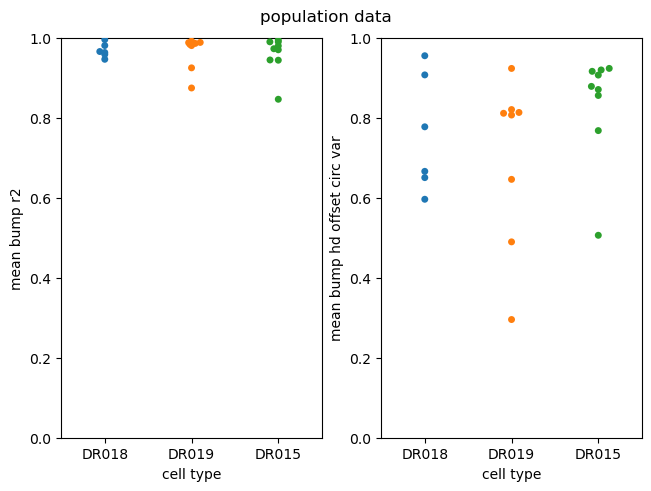

In [20]:
import seaborn as sns

category = 'cell_type'
stats = ['mean_bump_r2', 'mean_bump_hd_offset_circ_var']

fig, ax = plt.subplots(1, 2,
                       layout='constrained')
for index, stat in enumerate(stats):

    sns.swarmplot(data=processed_expt_df, x=category, y=stat,
                  ax=ax[index])
    ax[index].set_ylim([0,1])
    ax[index].set_xlabel(" ".join(category.split('_')))
    ax[index].set_ylabel(" ".join(stat.split('_')))

fig.suptitle("population data")

# Save plot
for fmt in PLOT_FORMATS:
    fig.savefig(Path(OUTPUT_FOLDER, "population_data" + fmt), dpi=600)

# Save raw stats
processed_expt_df.to_csv(Path(OUTPUT_FOLDER, "population_data.csv"))

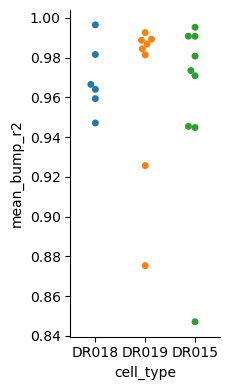

In [21]:
g = sns.catplot(
    data=processed_expt_df, x="cell_type", y='mean_bump_r2',
    kind="swarm", height=4, aspect=.6,
)


### Plot Each trial individually

In [22]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile\individual_trials")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [23]:
CELL_TYPES = ["DR015", "DR018", "DR019"]

GENETIC_TOOLS = ["iGluSnFR"]

In [24]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

# Remove empty experiments:
empty_expt_idxs = []
for idx, expt in processed_expt_df['expt'].items():
    if expt.synced_df is None:
        empty_expt_idxs.append(idx)
processed_expt_df = processed_expt_df.drop(index=empty_expt_idxs)

2024-09-30 11:38:06,147 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240116_DR018xiGluSnFr_Fly1_00001 is missing synced_df, removing from Experiment.
2024-09-30 11:38:06,153 - INFO - gulp2p.preproc.experiment - [experiment.py filter_trials() 58] - Trial 20240117_DR019xiGluSnFr_Fly2_00004 is missing synced_df, removing from Experiment.
C:\Users\ahshenas\AppData\Local\Temp\ipykernel_21236\2055239172.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)


In [25]:
# Plot Individual trials
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        trial_expt = Experiment(trials=[trial])
        logger.info(f"Plotting trial {trial_expt.trials[0].name}")
        try:
            fig, axd = plotting.plot_expt(trial_expt)
        except:
            continue
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial_{trial_metadata['trial']:0>2}"
        # print(fig_title)
        fig.suptitle(fig_title)
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)


2024-09-30 11:38:06,836 - INFO - __main__ - [2703234266.py <module>() 10] - Plotting trial 20231206_DR018xiGluSnFr_Fly1_00001
2024-09-30 11:38:06,899 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1595 nans / 2611 total elements
2024-09-30 11:38:06,904 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2032 nans / 2611 total elements
2024-09-30 11:38:06,913 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 1595 nans / 2611 total elements
2024-09-30 11:38:06,916 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2032 nans / 2611 total elements
2024-09-30 11:38:06,921 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 2206 n

In [26]:
## Plot PB with ROI's
for index, expt_df_row in processed_expt_df.iterrows():
    expt = expt_df_row['expt']

    output_dir = Path(OUTPUT_FOLDER, expt_df_row['expt_name'])
    output_dir.mkdir(exist_ok=True, parents=True)

    for trial in expt.trials:
        fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
        plotting.plot_roi(expt.trials[0], ax)
        ax.set_title("")
        trial_metadata = tr.parse_trial_name(trial.path, CELL_TYPES, GENETIC_TOOLS)
        fig_title = f"{trial_metadata['date']}_{trial_metadata['line']}_Fly{trial_metadata['fly']}_Trial{trial_metadata['trial']:0>2}_PB_with_rois"
        for fmt in PLOT_FORMATS:
            fig.savefig(Path(output_dir, fig_title + fmt), dpi=600)
        plt.close(fig)

In [27]:
expt_df[expt_df['cell_type'] == 'DR015']

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
16,20231214_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
17,20231214_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231214\20231214_D...,20231214,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
22,20240118_DR015xiGluSnFr_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,1,[],0
23,20240118_DR015xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240118\20240118_D...,20240118,DR015xiGluSnFr,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,5
33,20240618_DR015xiGluSNfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240618\20240618_D...,20240618,DR015xiGluSNfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,7
34,20240620_DRo15xiGluSnFR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240620\20240620_D...,20240620,DRo15xiGluSnFR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,8
35,20240626_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2
36,20240626_DR015xiGluSnfR_Fly2,[Z:\2PImaging\Kerstin\MIMS\20240626\20240626_D...,20240626,DR015xiGluSnfR,DR015,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,4
37,20240702_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240702\20240702_D...,20240702,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,14
38,20240708_DR015xiGluSnfR_Fly1,[Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGlu...,20240708,DR015xiGluSnfR,DR015,iGluSnFR,1,[<gulp2p.preproc.trial.Trial object at 0x00000...,2


### Examine 20240125_DR019xiGluSnFR_Fly02_00005 more closely

In [28]:
OUTPUT_FOLDER = Path(r"Z:\GULP\results\bump_profile")
OUTPUT_FOLDER.mkdir(exist_ok=True, parents=True)

PLOT_FORMATS = [".png", ".svg"]

In [29]:
# tiff_path = Path(r"Z:\2PImaging\Kerstin\MIMS\20240708\DR015xiGluSnfR_fly2_00001.tif")
root_tiff_folder = Path(r"Z:\2PImaging\Kerstin\MIMS\20231212")

In [30]:
trial_df = tr.create_trial_df(root_tiff_folder, CELL_TYPES, GENETIC_TOOLS)

In [31]:
trial_df

,path,date,line,cell_type,genetic_tool,fly,trial
0,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,1
1,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,2
2,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,3
3,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,4
4,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,5
5,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,6
6,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,7
7,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,8
8,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,9
9,Z:\2PImaging\Kerstin\MIMS\20231212\20231212_DR...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,1,10


In [32]:
trial_df = trial_df[(trial_df['fly']==2) & (trial_df['trial']==3)]

In [33]:
expt_df = create_expt_df(trial_df, CELL_TYPES, GENETIC_TOOLS)

In [34]:
expt_df

,expt_name,trial_paths,date,line,cell_type,genetic_tool,fly,trials,proc_trial_count
0,20231212_DR018xiGluSnFr_Fly2,[Z:\2PImaging\Kerstin\MIMS\20231212\20231212_D...,20231212,DR018xiGluSnFr,DR018,iGluSnFR,2,[<gulp2p.preproc.trial.Trial object at 0x00000...,1


In [35]:
processed_expt_df = expt_df[expt_df['proc_trial_count'] > 0]
processed_expt_df['expt'] = processed_expt_df['trials'].apply(Experiment)

In [36]:
# def filter_mean_rois(mean_rois, circ_rs, min_r=0.15):
#     # in place change
#     if np.issubdtype(mean_rois.dtype, np.integer):
#         empty_value = -1
#     else:
#         empty_value = np.nan

#     filtered_mean_rois = np.copy(mean_rois)

#     mask = (circ_rs <  min_r)
#     filtered_mean_rois[mask] = empty_value
#     if np.isnan(filtered_mean_rois).all():
#         logger.warning(f"No circular mean found with r >= {min_r}")
#     return filtered_mean_rois



# bump_region = "mean"

# upper_deltaf = np.array(expt.synced_df.iloc[:, expt.rois_per_arm:expt.num_rois])
# lower_deltaf = np.array(expt.synced_df.iloc[:, 0:expt.rois_per_arm])

# if bump_region == "upper":
#     deltaf = upper_deltaf
# if bump_region == "lower":
#     deltaf = lower_deltaf
# if bump_region == "mean":
#     deltaf = np.mean(np.array([upper_deltaf, lower_deltaf]), axis=0)

# mean_rois = plotting.get_mean_rois(deltaf, precise=True)
# circ_rs = plotting.get_circ_rs(deltaf)
# filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=0.3)
# # Check if filter_mean_rois filtered out all points
# if np.isnan(filtered_mean_rois).all():
#     min_r = np.quantile(circ_rs, 1-0.1)
#     print(f"refiltering circular means with r >= {min_r}")
#     filtered_mean_rois = filter_mean_rois(mean_rois, circ_rs, min_r=min_r)


# int_head_direction = ((filtered_mean_rois * 360 / 8)) % 360
# ext_head_direction = (expt.synced_df.angle) % 360

# hd_offset = (int_head_direction - ext_head_direction) % 360

# print(f"filtered_mean_rois all nan: {np.isnan(filtered_mean_rois).all()}")
# print(f"int_head_direction all nan: {np.isnan(int_head_direction).all()}")
# print(f"ext_head_direction all nan: {np.isnan(ext_head_direction).all()}")

In [37]:
# imaging.process_all(tiff_paths, save=True, skip=False, use_full_volume=False)

2024-09-30 11:50:25,024 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4176 nans / 4195 total elements
2024-09-30 11:50:25,039 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4193 nans / 4195 total elements
2024-09-30 11:50:25,062 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4176 nans / 4195 total elements
2024-09-30 11:50:25,072 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4193 nans / 4195 total elements
2024-09-30 11:50:25,090 - DEBUG - gulp2p.analysis.head_direction - [head_direction.py get_internal_head_direction() 186] - Internal head direction: 4195 nans / 4195 total elements
C:\Users\ahshenas\Documents\GitHub\GULP\gulp2p\analysis\head_direction.py:123: RuntimeWarning: angle

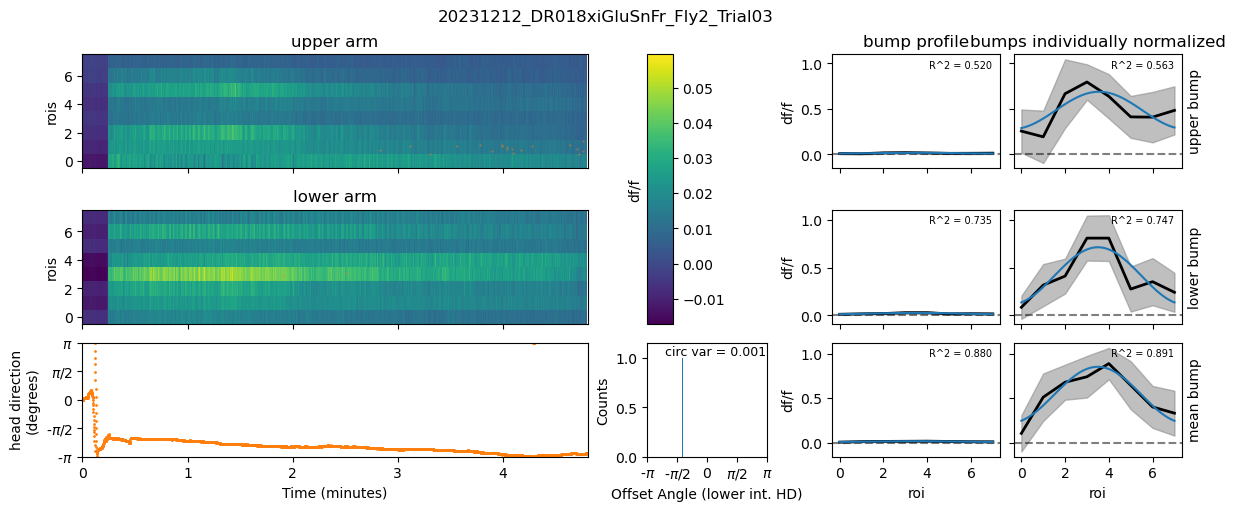

In [38]:

for index, expt_df_row in processed_expt_df.iterrows():
    # Plot experiment
    expt = expt_df_row['expt']

    logger.debug(f"{expt_df_row['expt_name']}")
    # print(expt_df_row['expt_name'])
    fig, axd = plotting.plot_expt(expt)

    fig_title = expt_df_row['expt_name'] + f"_Trial{expt.trials[0].name[-2:]}"
    fig.suptitle(fig_title)
    # for fmt in PLOT_FORMATS:
    #     fig.savefig(Path(OUTPUT_FOLDER, fig_title + fmt), dpi=600)

Text(0.5, 1.0, '')

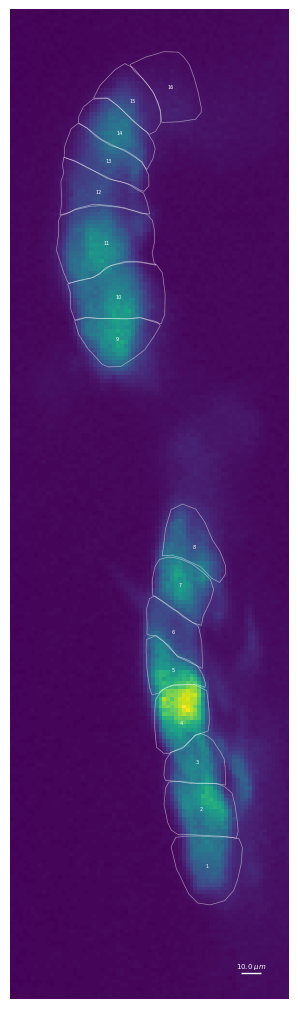

In [39]:
fig, ax = plt.subplots(figsize=(5,10), layout="constrained")
plotting.plot_roi(expt.trials[0], ax)
ax.set_title("")
# for fmt in PLOT_FORMATS:
#     fig.savefig(Path(OUTPUT_FOLDER, fig_title + "PB_with_rois" + fmt), dpi=600)

In [40]:
# plot offset of ext and int hd
# Plot circ var of offset

upper_deltaf = expt.upper_deltaf
lower_deltaf = expt.lower_deltaf

circ_means = hd.get_circ_mean_rois(upper_deltaf, precise=True)
circ_rs = hd.get_circ_rs(upper_deltaf)
filtered_mean_rois = hd.filter_circ_means(circ_means, circ_rs, min_r=0.3)

int_visual_shift = -120
int_head_direction = ((circ_means * 360 / 8) + int_visual_shift) % 360

In [41]:
ext_visual_shift = 180
ext_head_direction = (expt.synced_df.angle * 1 + ext_visual_shift) % 360

In [42]:
offset_visual_shift = 180
hd_offset =  (int_head_direction - ext_head_direction + offset_visual_shift) % 360

In [43]:
Y_pred = hd_offset
Y_true = np.full(hd_offset.shape, hd_offset.mean())
offset_mse = np.square(np.subtract(Y_true,Y_pred)).mean() 

Text(0.99, 0.95, 'circ R = 0.839')

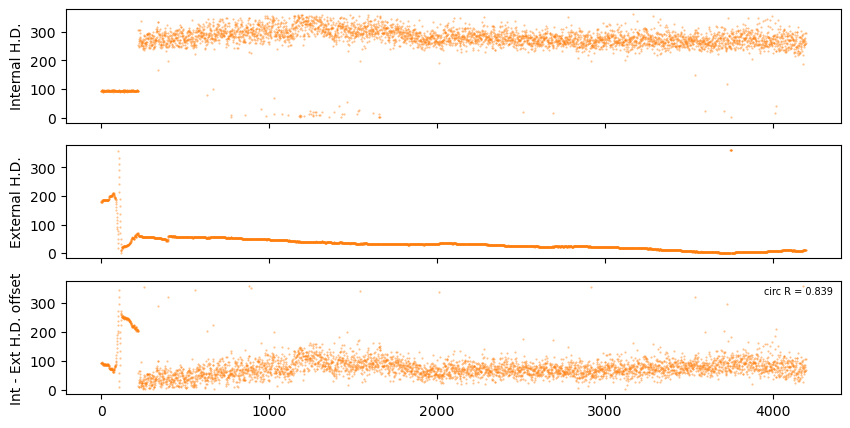

In [44]:
fig, axs = plt.subplots(3, figsize=(10,5), sharex=True)
axs[0].plot(int_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[0].set_ylabel("Internal H.D.")
axs[1].plot(ext_head_direction, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[1].set_ylabel("External H.D.")
axs[2].plot(hd_offset, marker='o', linestyle="", ms=0.5, color="C1", alpha=0.5)
axs[2].set_ylabel("Int - Ext H.D. offset")

# axs[0].set_xlim(5000, 10000)

circ_r = pingouin.circ_r(pingouin.convert_angles(hd_offset))
metric = f"circ R = {circ_r:.3f}"
axs[2].text(0.99, 0.95, metric, fontsize=7,
        transform=axs[2].transAxes, ha='right', va='top')